In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load data and initial setup

In [9]:
# Load the dataset
df = pd.read_csv(r'C:\Users\Asus\Documents\Projects\Bangladesh-Railway-Ticket-Demand-Prediction-System\notebook\data\bangladesh_railway_tickets.csv' \
'')

In [10]:
print("Data shape:", df.shape)

Data shape: (100000, 15)


In [11]:
print("\nColumn names and data types:")
print(df.dtypes)


Column names and data types:
Ticket No          object
Issue Date         object
Issue Time         object
Passenger Name     object
From               object
To                 object
Train Name         object
Train No          float64
Departure Time     object
Coach              object
Seat Number        object
Seats Booked      float64
Fare              float64
Payment Method     object
 Journey Date      object
dtype: object


In [12]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
      Ticket No  Issue Date Issue Time Passenger Name        From          To  \
0  BR8478729720   4/25/2026   13:19:56  Rakib Hossain  Chattogram      Sylhet   
1  BR7219153552    3/3/2026    2:38:16   Tanvir Hasan       Dhaka  Chattogram   
2  BR8520704729    6/6/2026   21:53:02    Rifat Islam  Chattogram      Sylhet   
3  BR8941235199  11/11/2026    2:53:22    Abdul Karim       Dhaka  Chattogram   
4  BR2320871590   7/20/2026   21:45:03    Sadia Afrin       Dhaka      Sylhet   

          Train Name  Train No Departure Time         Coach Seat Number  \
0   Paharika Express     783.0        8:15 PM        Shovon         B19   
1    Subarna Express     701.0        7:00 AM  Non-AC Berth         C18   
2   Chattala Express     781.0        7:00 AM  Shovon Chair          B6   
3  Mohanagar Express     727.0        9:00 AM  Non-AC Berth          B8   
4     Upaban Express     751.0        6:15 AM        Shovon          B2   

   Seats Booked    Fare Payment Method  Journey

### Data Cleaning

In [13]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Ticket No         1
Issue Date        0
Issue Time        1
Passenger Name    1
From              1
To                1
Train Name        1
Train No          1
Departure Time    1
Coach             1
Seat Number       1
Seats Booked      1
Fare              1
Payment Method    1
 Journey Date     0
dtype: int64


In [14]:
# Check duplicate rows
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")


Duplicate rows: 0


In [ ]:
# Load the dataset
df = pd.read_csv(r'C:\Users\Asus\Documents\Projects\Bangladesh-Railway-Ticket-Demand-Prediction-System\notebook\data\bangladesh_railway_tickets.csv')

# Check for inconsistent categories (e.g., unexpected values in categorical columns)
cat_cols = ['Type', 'Region', 'Sub-region'] # Updated with actual categorical columns from the dataframe
for col in cat_cols:
    print(f"{col} unique values: {df[col].unique()}")

NameError: name 'df' is not defined

###  EXPLORING DATA

In [ ]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 6 numerical features : ['Price', 'No. Beds', 'No. Baths', 'Area', 'Latitude', 'Longitude']

We have 4 categorical features : ['Location', 'Type', 'Region', 'Sub-region']


In [ ]:
# proportion of count data on categorical columns
for col in categorical_features:
    print(df[col].value_counts(normalize=True) * 100)
    print('---------------------------')

Location
West Shewrapara, Mirpur, Dhaka              2.359694
Uttar Badda, Badda, Dhaka                   2.295918
Sector 10, Uttara, Dhaka                    2.040816
Chandrima Model Town, Mohammadpur, Dhaka    1.977041
Ashkona, Dakshin Khan, Dhaka                1.849490
                                              ...   
Abdul Aziz Lane, Lalbagh, Dhaka             0.021259
Ibrahimpur Bazar Road, Ibrahimpur, Dhaka    0.021259
Jurain, Shyampur, Dhaka                     0.021259
South Chalabon, Dakshin Khan, Dhaka         0.021259
Block C, Niketan, Dhaka                     0.021259
Name: proportion, Length: 555, dtype: float64
---------------------------
Type
Apartment    94.982993
Plot          4.315476
Building      0.467687
Duplex        0.233844
Name: proportion, dtype: float64
---------------------------
Region
Mirpur            17.814626
Mohammadpur        8.524660
BashundharaR-A     7.227891
Uttara             6.994048
Badda              4.931973
                    ...    
K

### Univariate Analysis

In [ ]:
# Numerical variables
num_cols = ['Price', 'Area', 'No. Beds', 'No. Baths', 'Latitude', 'Longitude']

In [ ]:
# Summary statistics
print("\nDescriptive statistics for numerical features:")
print(df[num_cols].describe())


Descriptive statistics for numerical features:
              Price          Area     No. Beds    No. Baths     Latitude  \
count  4.704000e+03   4704.000000  4500.000000  4500.000000  4704.000000   
mean   1.001724e+07   1460.678146     2.981333     2.830889    23.780563   
std    9.787789e+06   1067.267396     1.456064     0.862690     0.047919   
min    5.000000e+05    320.000000     1.000000     1.000000    23.644560   
25%    5.000000e+06   1050.000000     3.000000     2.000000    23.752610   
50%    7.000000e+06   1275.000000     3.000000     3.000000    23.770260   
75%    1.080000e+07   1550.000000     3.000000     3.000000    23.812230   
max    8.131280e+07  43344.000000    46.000000    10.000000    23.893380   

         Longitude  
count  4704.000000  
mean     90.391496  
std       0.035239  
min      90.246430  
25%      90.365470  
50%      90.392800  
75%      90.421790  
max      90.480410  


In [ ]:
# Skewness and kurtosis
for col in num_cols:
    print(f"{col}: skewness = {skew(df[col]):.3f}, kurtosis = {kurtosis(df[col]):.3f}")

Price: skewness = 3.544, kurtosis = 16.053
Area: skewness = 16.330, kurtosis = 536.648
No. Beds: skewness = nan, kurtosis = nan
No. Baths: skewness = nan, kurtosis = nan
Latitude: skewness = -0.054, kurtosis = -0.107
Longitude: skewness = -0.837, kurtosis = 2.683


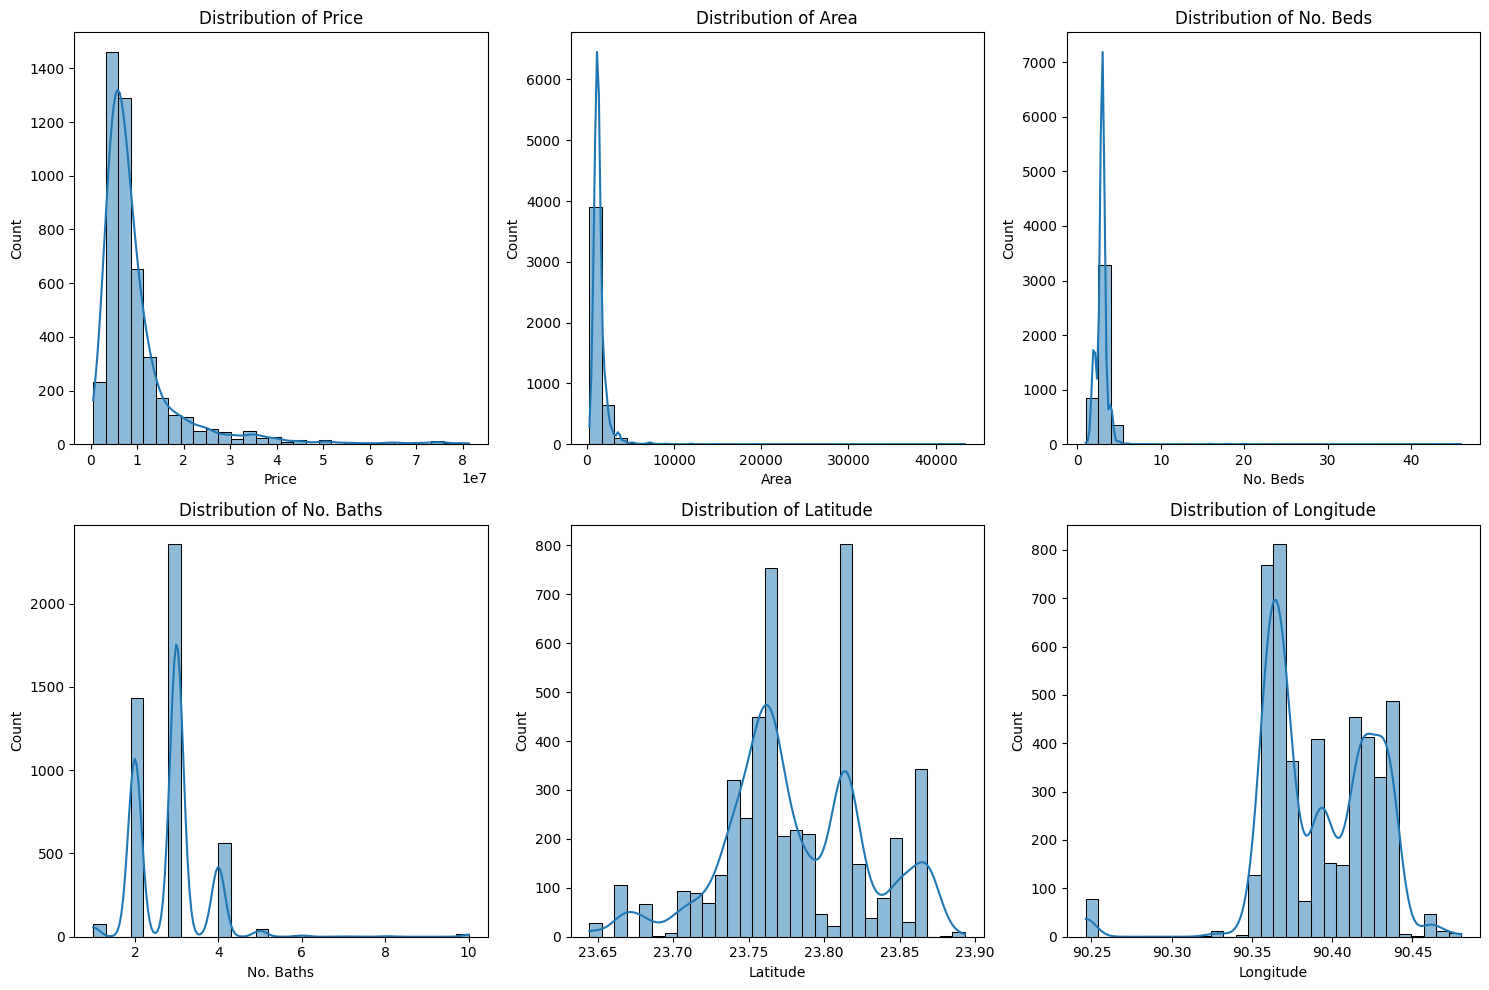

In [ ]:
# Histograms with KDE
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### Categorical Features

In [ ]:
# Categorical variables
cat_cols = ['Location', 'Type', 'Region', 'Sub-region']

In [ ]:
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True))


Location:
Location
West Shewrapara, Mirpur, Dhaka              111
Uttar Badda, Badda, Dhaka                   108
Sector 10, Uttara, Dhaka                     96
Chandrima Model Town, Mohammadpur, Dhaka     93
Ashkona, Dakshin Khan, Dhaka                 87
                                           ... 
Abdul Aziz Lane, Lalbagh, Dhaka               1
Ibrahimpur Bazar Road, Ibrahimpur, Dhaka      1
Jurain, Shyampur, Dhaka                       1
South Chalabon, Dakshin Khan, Dhaka           1
Block C, Niketan, Dhaka                       1
Name: count, Length: 555, dtype: int64
Location
West Shewrapara, Mirpur, Dhaka              0.023597
Uttar Badda, Badda, Dhaka                   0.022959
Sector 10, Uttara, Dhaka                    0.020408
Chandrima Model Town, Mohammadpur, Dhaka    0.019770
Ashkona, Dakshin Khan, Dhaka                0.018495
                                              ...   
Abdul Aziz Lane, Lalbagh, Dhaka             0.000213
Ibrahimpur Bazar Road, Ibrahimpur

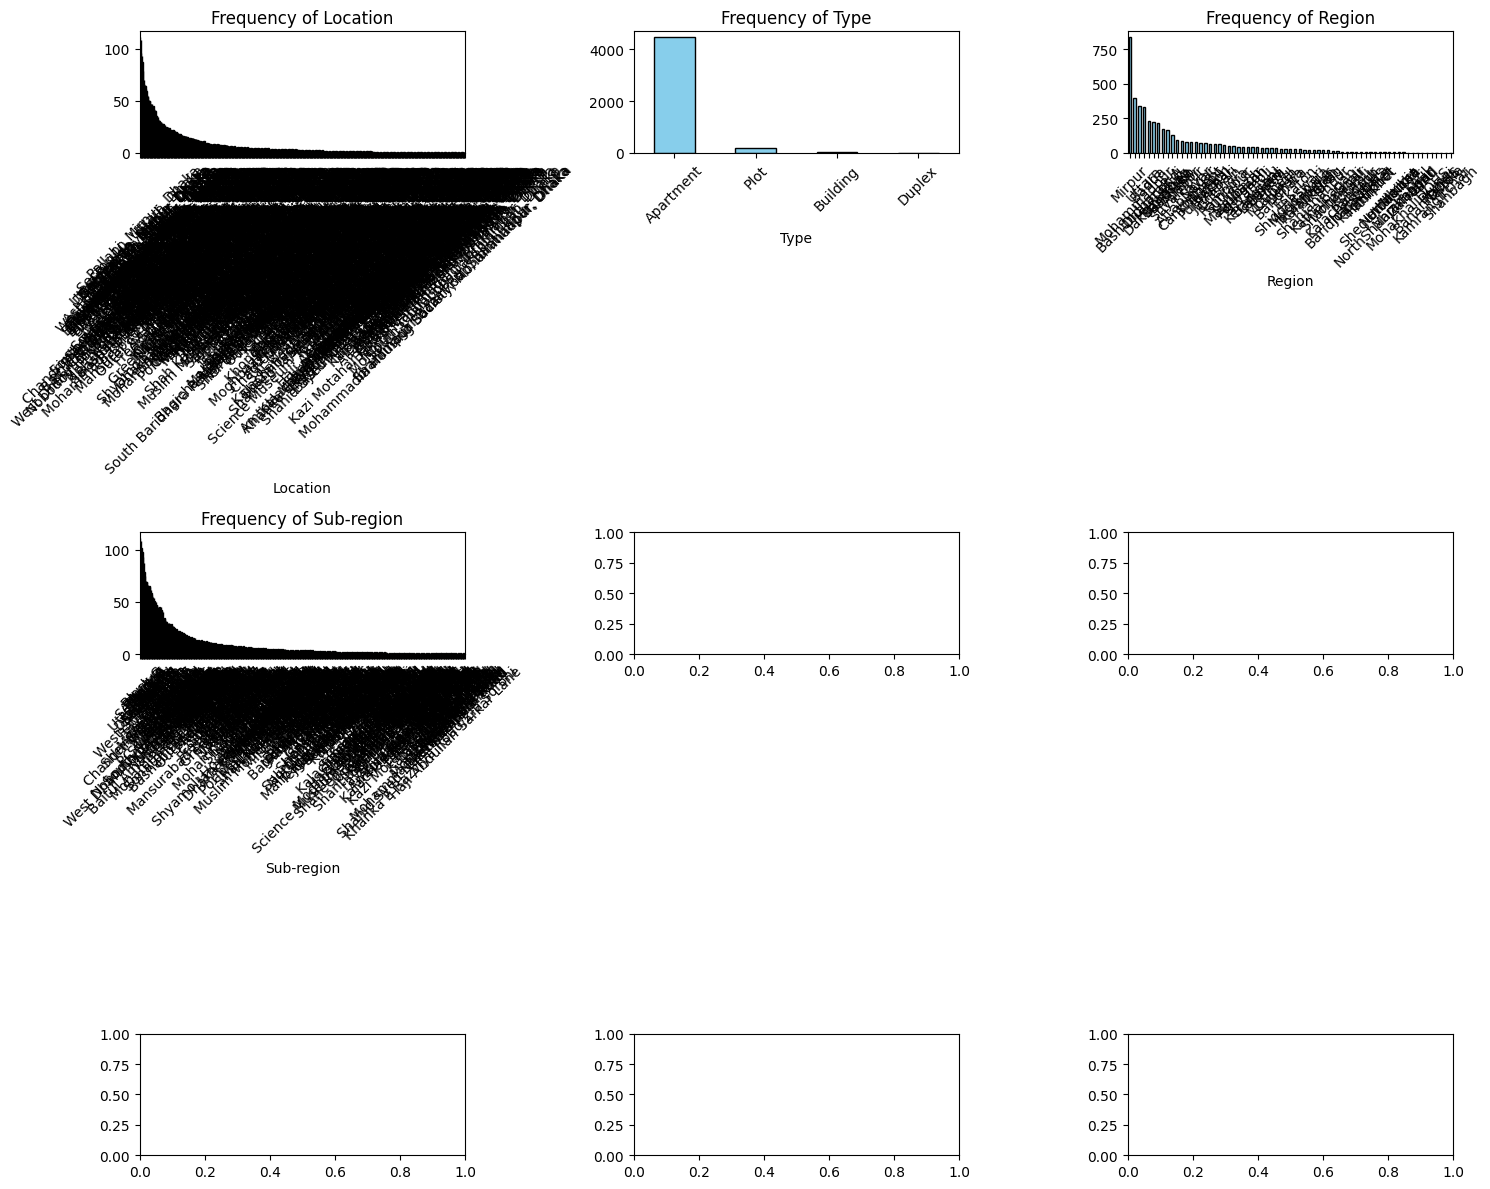

In [ ]:
# Bar charts
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'Frequency of {col}')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

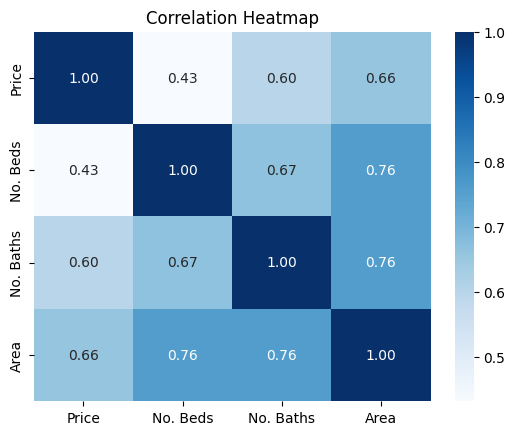

In [ ]:
# Correlation heatmap
corr = df[['Price', 'No. Beds', 'No. Baths', 'Area']].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### Bivariate Analysis

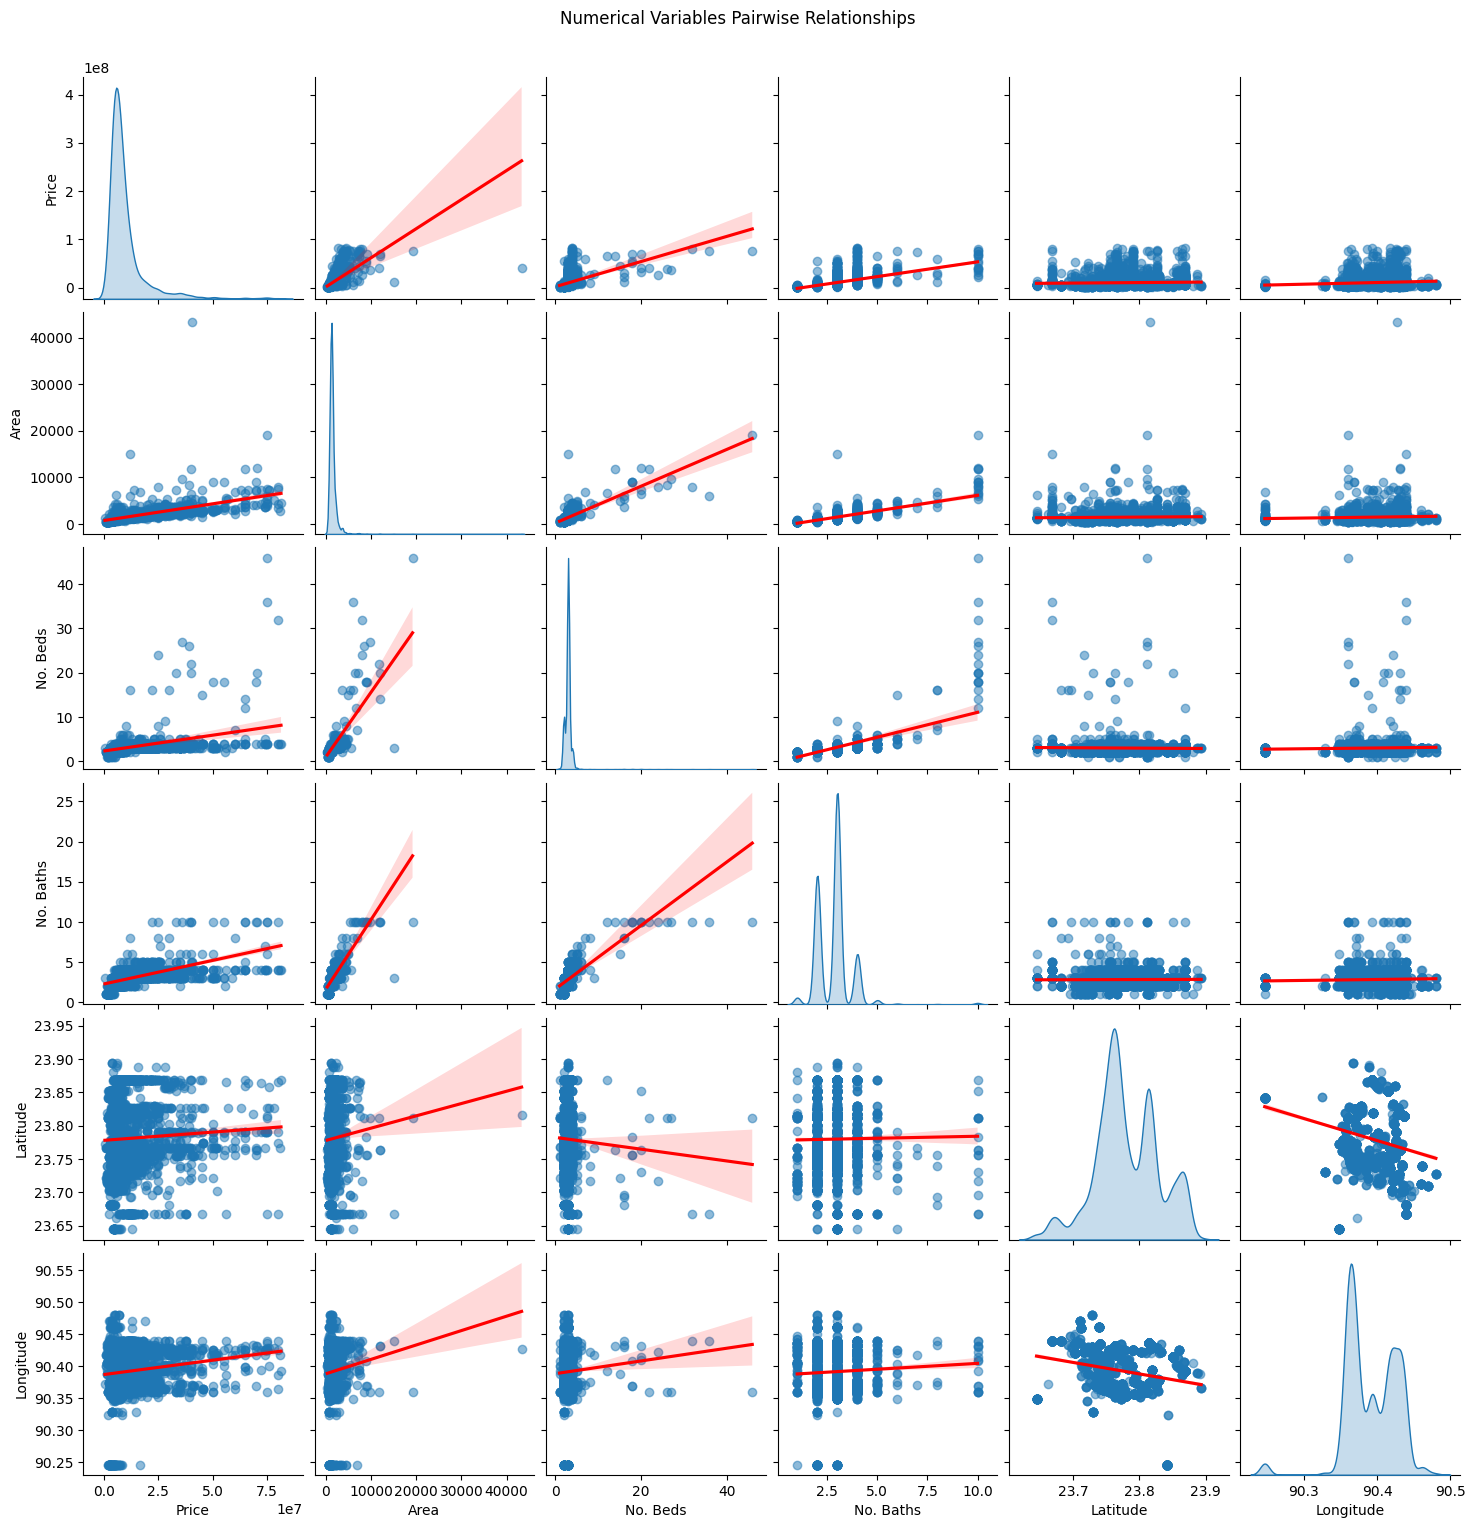

In [ ]:
# Scatter plots with regression lines
sns.pairplot(df[num_cols], diag_kind='kde', kind='reg',
             plot_kws={'line_kws': {'color': 'red'}, 'scatter_kws': {'alpha': 0.5}})
plt.suptitle('Numerical Variables Pairwise Relationships', y=1.02)
plt.show()

In [ ]:
# Pearson and Spearman correlations
pearson_corr = df[num_cols].corr(method='pearson')
spearman_corr = df[num_cols].corr(method='spearman')
print("Pearson correlation with Price:")
print(pearson_corr['Price'].sort_values(ascending=False))
print("\nSpearman correlation with Price:")
print(spearman_corr['Price'].sort_values(ascending=False))

Pearson correlation with Price:
Price        1.000000
Area         0.658100
No. Baths    0.599200
No. Beds     0.431709
Longitude    0.124712
Latitude     0.050416
Name: Price, dtype: float64

Spearman correlation with Price:
Price        1.000000
Area         0.872944
No. Baths    0.756844
No. Beds     0.603722
Longitude    0.113693
Latitude     0.029437
Name: Price, dtype: float64


### Categorical vs Target (price)

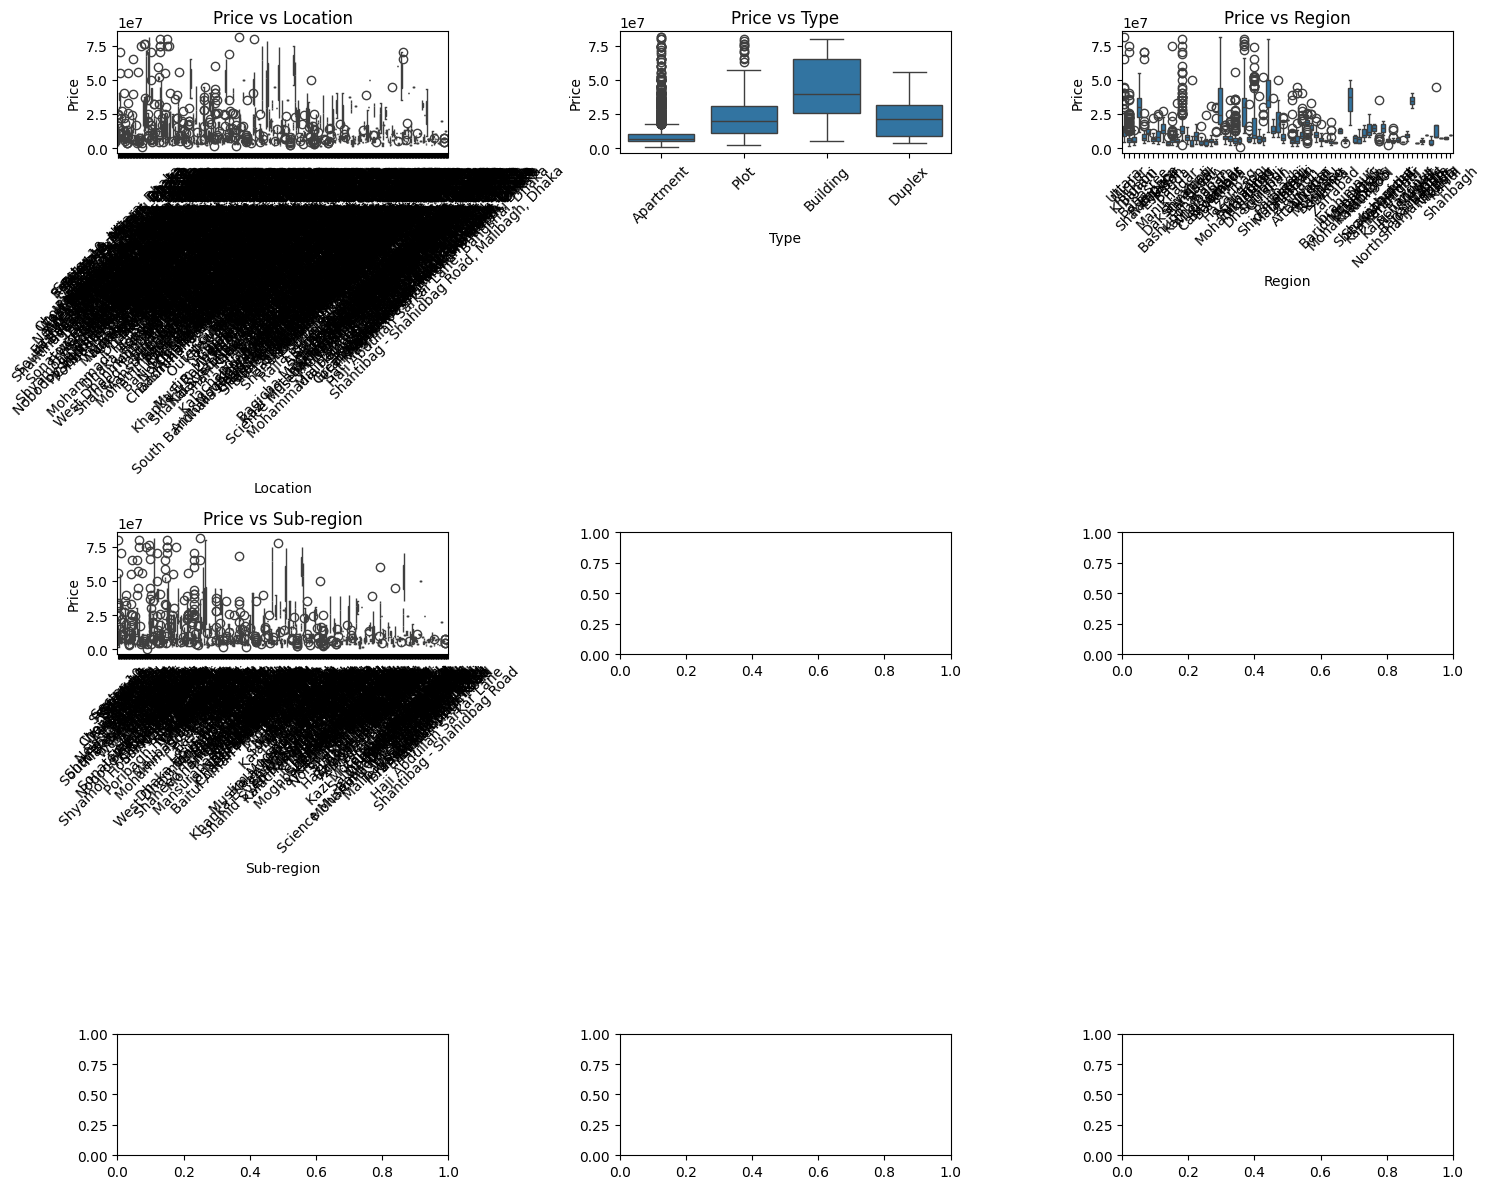

In [ ]:
# Boxplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.boxplot(x=df[col], y=df['Price'], ax=axes[i])
    axes[i].set_title(f'Price vs {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Statistical tests
for col in cat_cols:
    # Filter out NaN values from the column before getting unique categories
    valid_categories = df[col].dropna().unique()
    groups = [df[df[col] == cat]['Price'].dropna() for cat in valid_categories]

    # Ensure there are at least two groups with data for comparison
    if len(groups) > 1 and all(len(g) > 0 for g in groups):
        if len(groups) == 2:
            # t-test for two independent samples
            stat, p = ttest_ind(groups[0], groups[1])
            test = "t-test"
        else:
            # ANOVA for more than two groups
            try:
                stat, p = f_oneway(*groups)
                test = "ANOVA"
            except ValueError:
                print(f"Cannot perform ANOVA for {col}: not enough data in groups.")
                continue
        print(f"{col} ({test}): p-value = {p:.5f}")
    else:
        print(f"Cannot perform statistical test for {col}: not enough valid groups or data.")

Location (ANOVA): p-value = 0.00000
Type (ANOVA): p-value = 0.00000
Region (ANOVA): p-value = 0.00000
Sub-region (ANOVA): p-value = 0.00000


### Categorical vs Categorical

In [ ]:
# Chi-square tests
chi_results = []
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        col1, col2 = cat_cols[i], cat_cols[j]
        contingency = pd.crosstab(df[col1], df[col2])
        chi2, p, dof, expected = chi2_contingency(contingency)
        chi_results.append({'Feature1': col1, 'Feature2': col2, 'Chi2': chi2, 'p-value': p})
chi_df = pd.DataFrame(chi_results)
print(chi_df.sort_values('p-value').to_string(index=False))

Feature1   Feature2         Chi2  p-value
Location       Type 6.133875e+03      0.0
Location     Region 3.198720e+05      0.0
Location Sub-region 2.134080e+06      0.0
    Type     Region 2.290725e+03      0.0
    Type Sub-region 4.900756e+03      0.0
  Region Sub-region 2.781156e+05      0.0


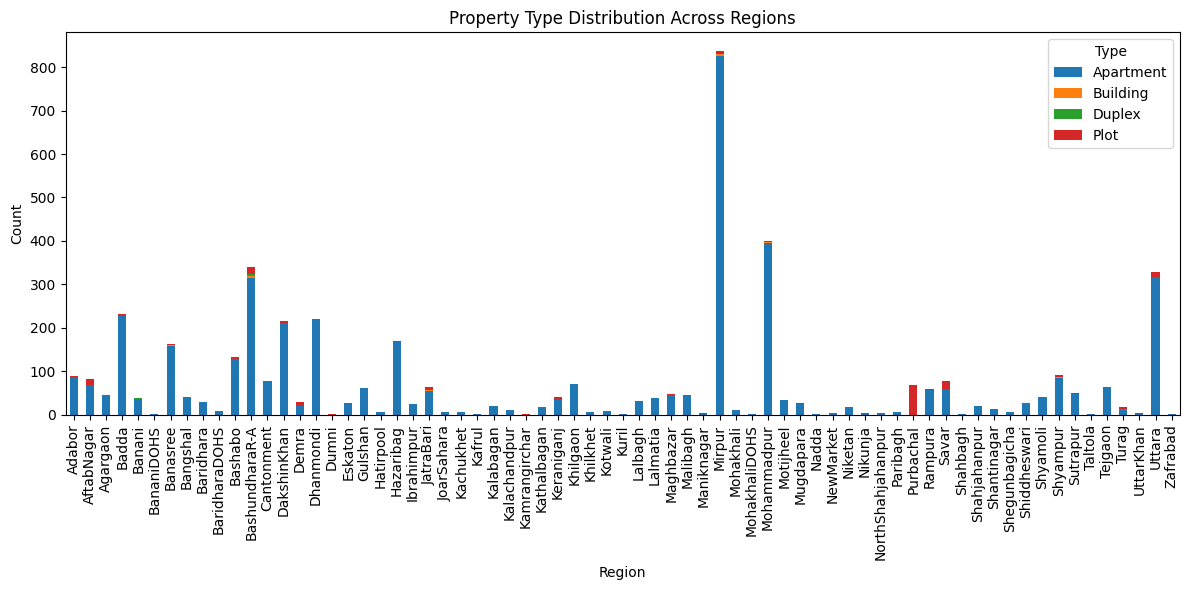

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
pd.crosstab(df['Region'], df['Type']).plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Property Type Distribution Across Regions')
ax.set_xlabel('Region')
ax.set_ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

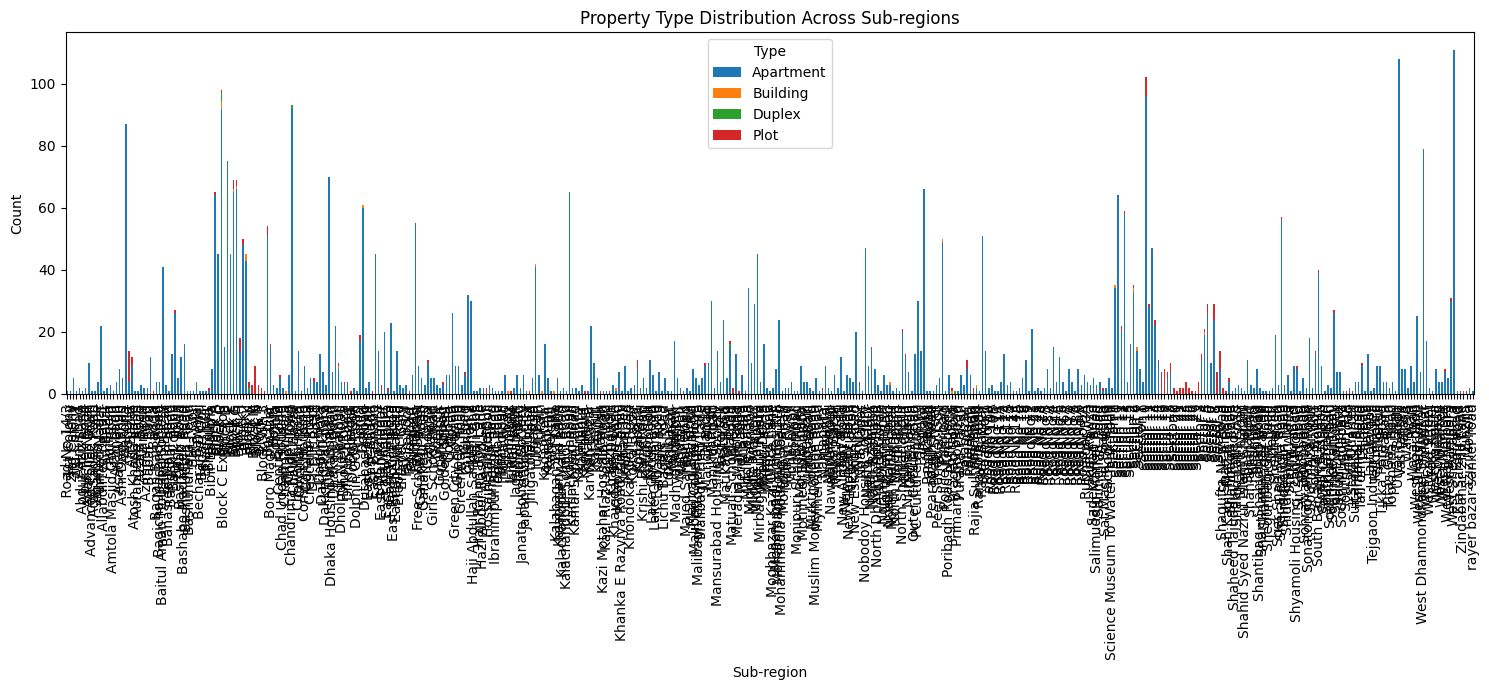

In [ ]:
fig, ax = plt.subplots(figsize=(15, 7))
pd.crosstab(df['Sub-region'], df['Type']).plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Property Type Distribution Across Sub-regions')
ax.set_xlabel('Sub-region')
ax.set_ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

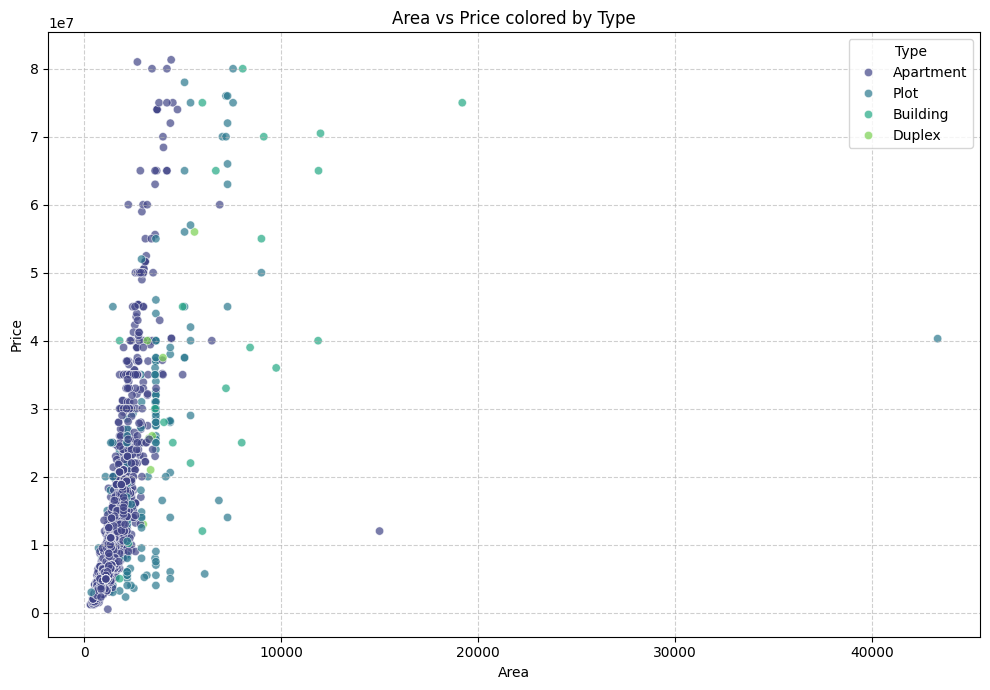

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Area', y='Price', hue='Type', palette='viridis', alpha=0.7)
plt.title('Area vs Price colored by Type')
plt.xlabel('Area')
plt.ylabel('Price')
plt.legend(title='Type')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Multivariate Analysis

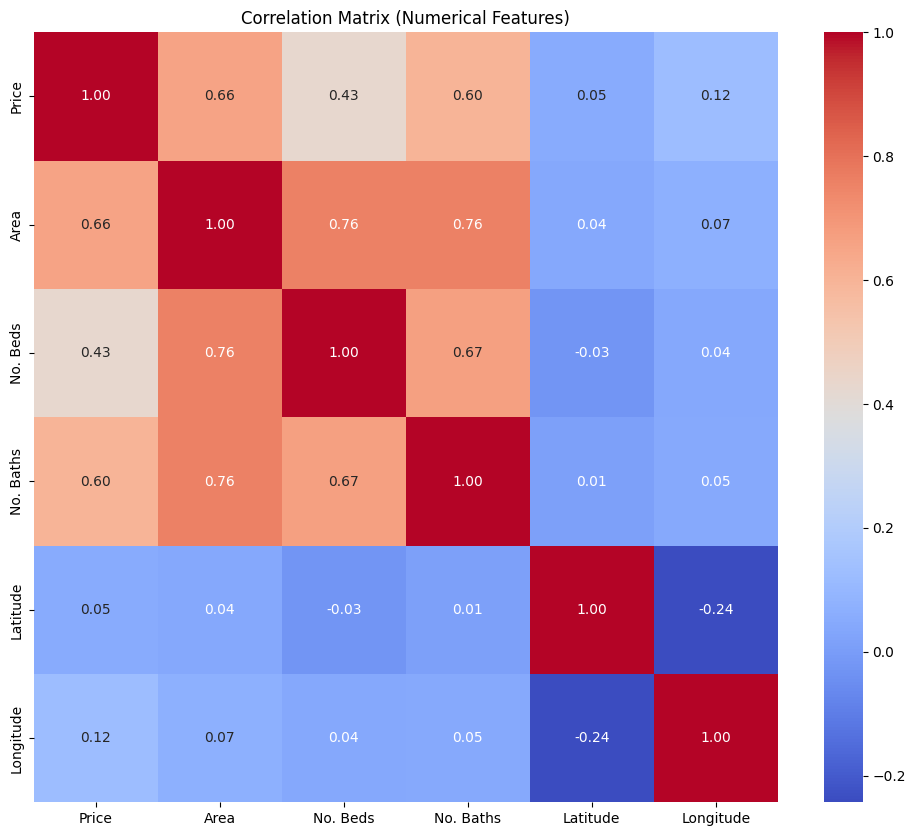

In [ ]:
# Encode binary categoricals as 0/1
df_enc = df.copy()
# The following lines are commented out as the columns 'mainroad', 'guestroom', 'basement',
# 'hotwaterheating', 'airconditioning', 'prefarea', and 'furnishingstatus' do not exist in the current DataFrame 'df'.
# for col in ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']:
#     df_enc[col] = df_enc[col].map({'yes':1, 'no':0})
# furn_map = {'unfurnished':0, 'semi-furnished':1, 'furnished':2}
# df_enc['furnishingstatus'] = df_enc['furnishingstatus'].map(furn_map)

# Calculate correlation only for numerical columns
plt.figure(figsize=(12, 10))
sns.heatmap(df_enc[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (Numerical Features)')
plt.show()

### Dimensionality Reduction (PCA & t-SNE)

In [ ]:
# Scale numerical data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_cols])

Text(0, 0.5, 'PC2')

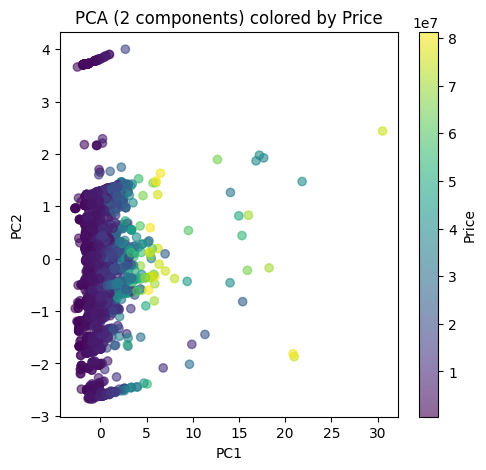

In [ ]:
# PCA
pca = PCA(n_components=2)

# Impute missing values in 'No. Beds' and 'No. Baths' before scaling for PCA.
# Create a temporary DataFrame for numerical features to impute.
df_pca_temp = df[num_cols].copy()
for col_impute in ['No. Beds', 'No. Baths']:
    if df_pca_temp[col_impute].isnull().any():
        median_val = df_pca_temp[col_impute].median()
        df_pca_temp[col_impute].fillna(median_val, inplace=True)

# Re-scale the imputed numerical data
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(df_pca_temp)

X_pca = pca.fit_transform(X_scaled_pca) # Use the clean scaled data
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
# Correct 'price' to 'Price'
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Price'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Price')
plt.title('PCA (2 components) colored by Price')
plt.xlabel('PC1')
plt.ylabel('PC2')

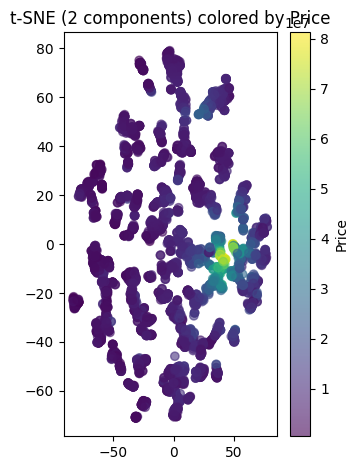

In [ ]:
# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

# Impute missing values in 'No. Beds' and 'No. Baths' before scaling for t-SNE.
# Create a temporary DataFrame for numerical features to impute.
df_tsne_temp = df[num_cols].copy()
for col_impute in ['No. Beds', 'No. Baths']:
    if df_tsne_temp[col_impute].isnull().any():
        median_val = df_tsne_temp[col_impute].median()
        df_tsne_temp[col_impute].fillna(median_val, inplace=True)

# Re-scale the imputed numerical data
scaler_tsne = StandardScaler()
X_scaled_tsne = scaler_tsne.fit_transform(df_tsne_temp)

X_tsne = tsne.fit_transform(X_scaled_tsne)
plt.subplot(1,2,2)
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=df['Price'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Price')
plt.title('t-SNE (2 components) colored by Price')
plt.tight_layout()
plt.show()

### Outlier Detection and Treatment

In [ ]:
# IQR method
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data < lower) | (data > upper)]

for col in num_cols:
    outliers = detect_outliers_iqr(df[col])
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")


Price: 455 outliers (9.67%)
Area: 347 outliers (7.38%)
No. Beds: 1221 outliers (25.96%)
No. Baths: 78 outliers (1.66%)
Latitude: 29 outliers (0.62%)
Longitude: 77 outliers (1.64%)


In [ ]:
# Z-score method
from scipy.stats import zscore

z_scores = np.abs(zscore(df[num_cols]))
outlier_z = (z_scores > 3).sum(axis=0)
for col, count in zip(num_cols, outlier_z):
    print(f"{col}: {count} outliers ({count/len(df)*100:.2f}%)")

Price: 114 outliers (2.42%)
Area: 48 outliers (1.02%)
No. Beds: 0 outliers (0.00%)
No. Baths: 0 outliers (0.00%)
Latitude: 0 outliers (0.00%)
Longitude: 77 outliers (1.64%)


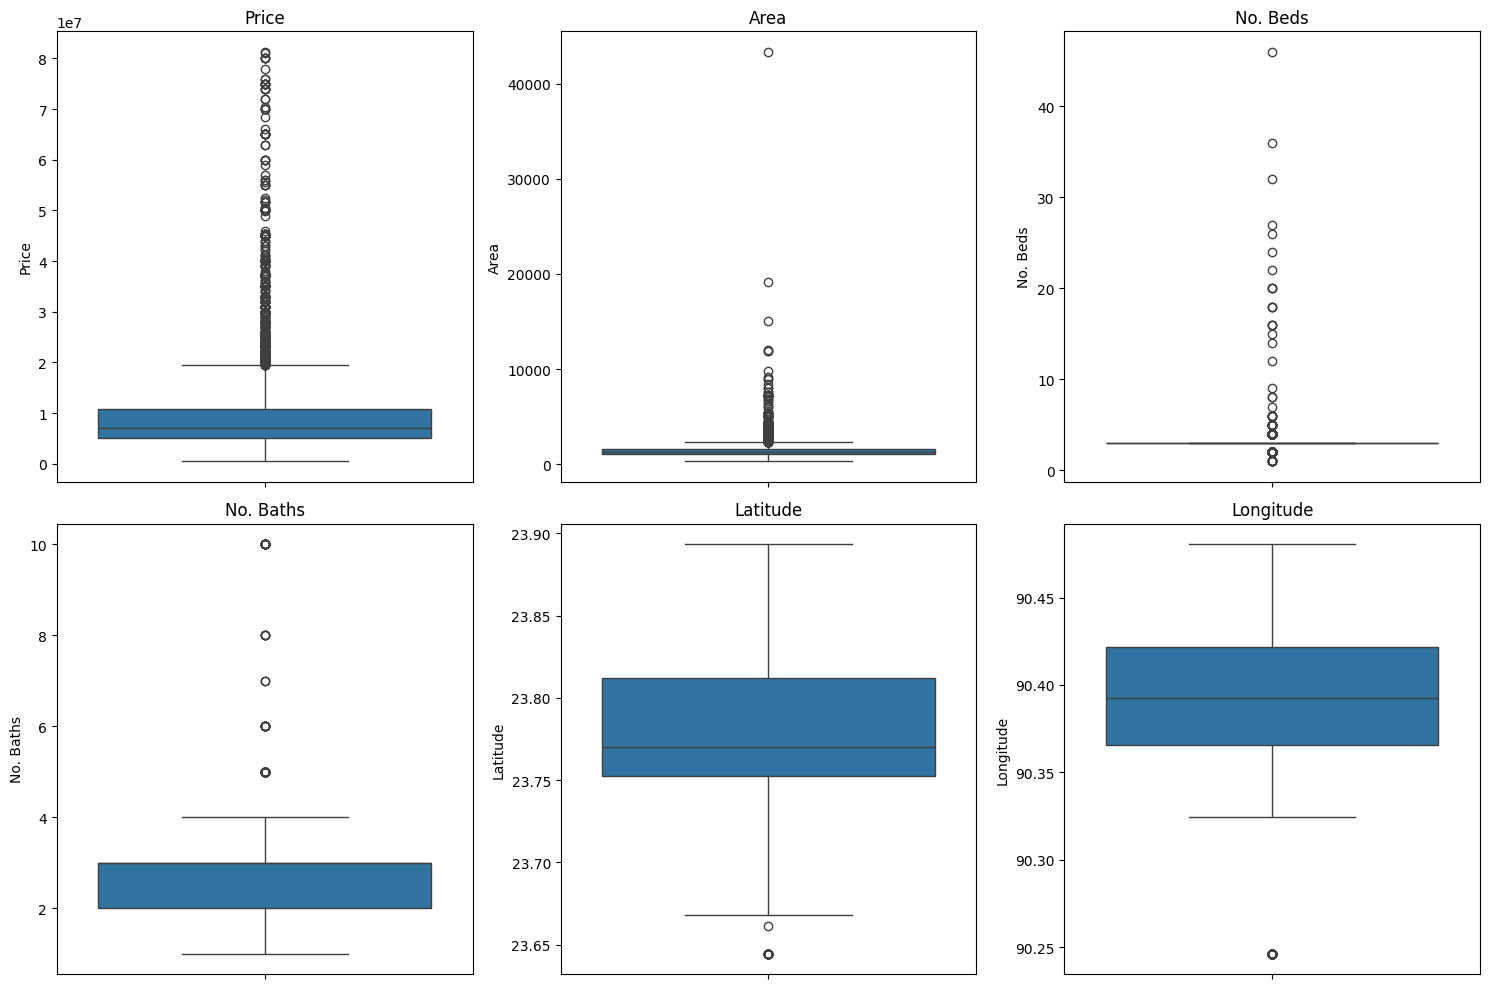

In [ ]:
# Boxplots for visual inspection
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Remove outliers from 'Price' and 'Area' iteratively
df_filtered = df.copy()
df_filtered = remove_outliers_iqr(df_filtered, 'Price')
df_filtered = remove_outliers_iqr(df_filtered, 'Area')

print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape (after removing Price and Area outliers): {df_filtered.shape}")

Original DataFrame shape: (4704, 10)
Filtered DataFrame shape (after removing Price and Area outliers): (4061, 10)


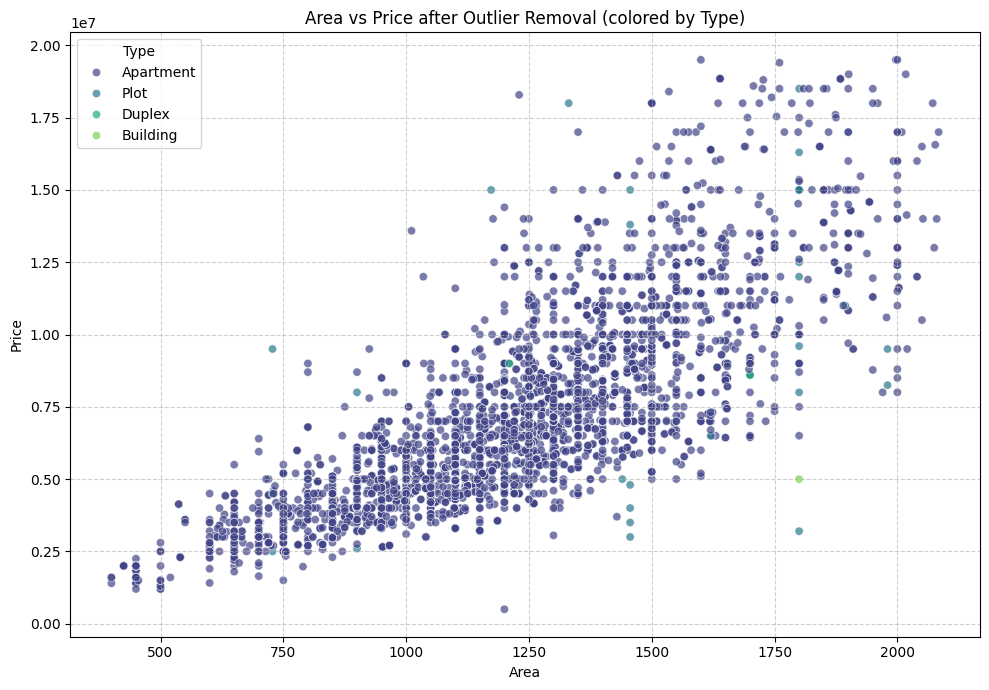

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_filtered, x='Area', y='Price', hue='Type', palette='viridis', alpha=0.7)
plt.title('Area vs Price after Outlier Removal (colored by Type)')
plt.xlabel('Area')
plt.ylabel('Price')
plt.legend(title='Type')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

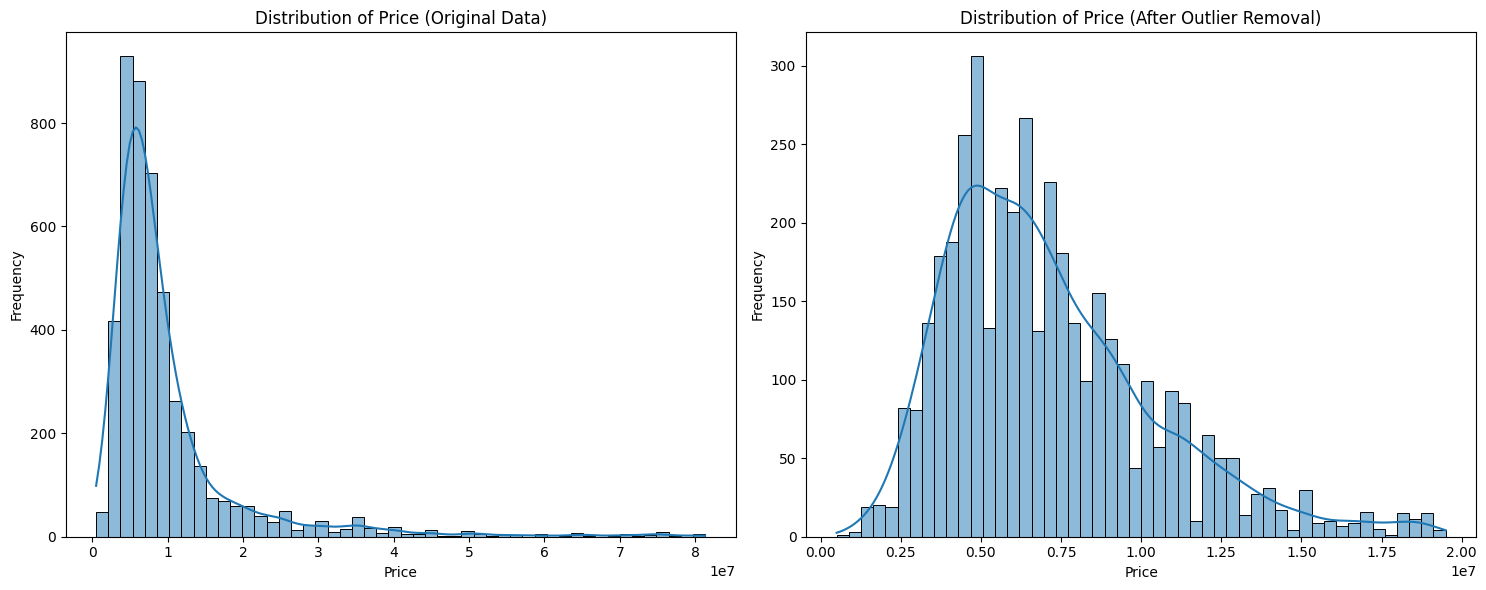

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df['Price'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Price (Original Data)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

sns.histplot(df_filtered['Price'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Price (After Outlier Removal)')
axes[1].set_xlabel('Price')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

# Prepare the data for regression
X = df_filtered[['Area']]
y = df_filtered['Price']

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Print the regression coefficients
print(f"Intercept: {model.intercept_:.2f}")
print(f"Coefficient for Area: {model.coef_[0]:.2f}")

Intercept: -3259057.14
Coefficient for Area: 8503.57


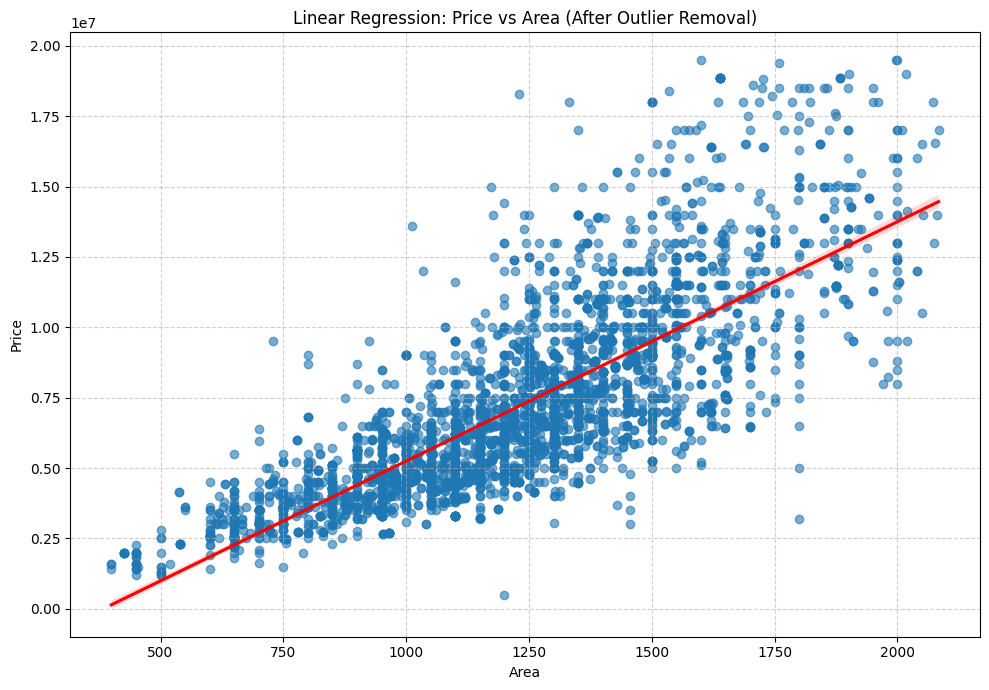

In [ ]:
plt.figure(figsize=(10, 7))
sns.regplot(x='Area', y='Price', data=df_filtered, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Linear Regression: Price vs Area (After Outlier Removal)')
plt.xlabel('Area')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

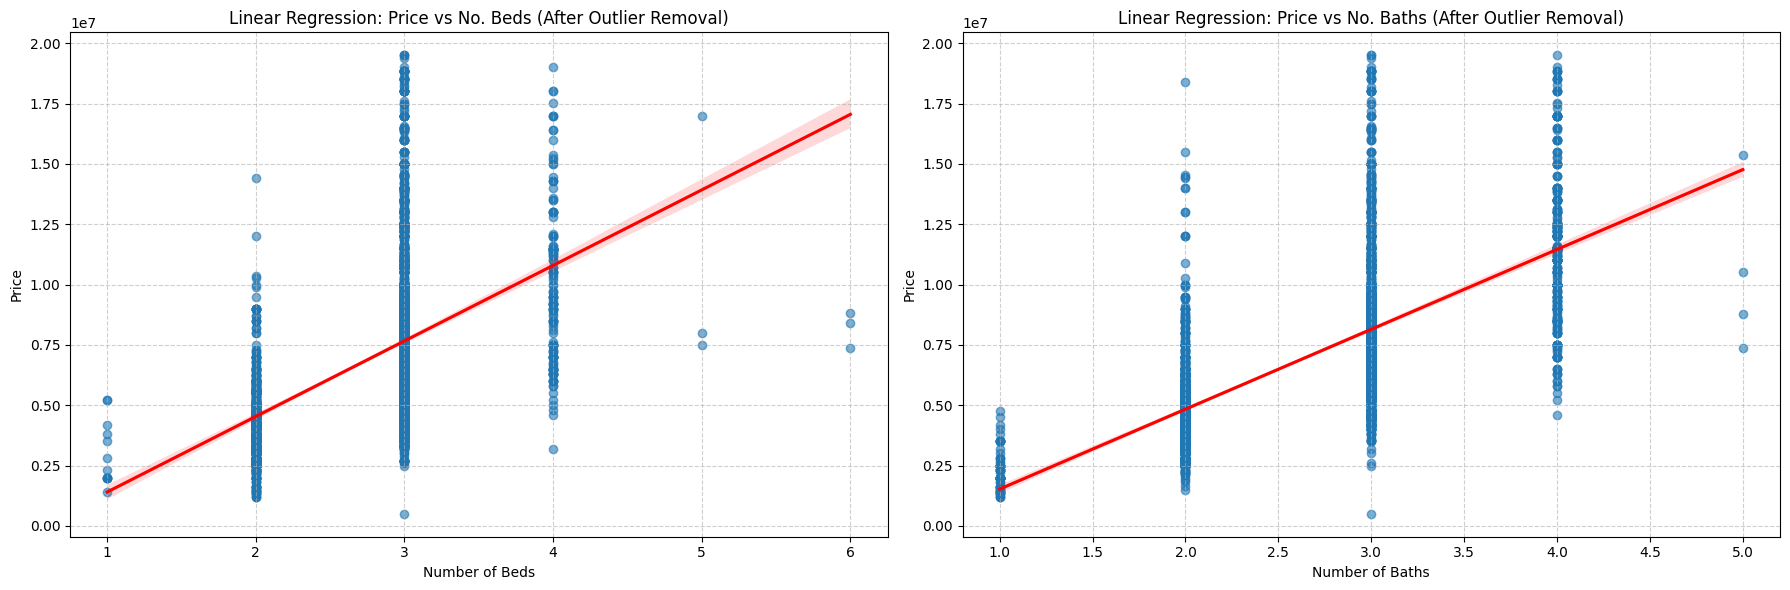

In [ ]:
# Impute missing values in 'No. Beds' and 'No. Baths' in the filtered dataframe
df_filtered_imputed = df_filtered.copy()

for col_impute in ['No. Beds', 'No. Baths']:
    if df_filtered_imputed[col_impute].isnull().any():
        median_val = df_filtered_imputed[col_impute].median()
        df_filtered_imputed[col_impute].fillna(median_val, inplace=True)

# Create scatter plots with regression lines
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.regplot(x='No. Beds', y='Price', data=df_filtered_imputed, scatter_kws={'alpha':0.6}, line_kws={'color':'red'}, ax=axes[0])
axes[0].set_title('Linear Regression: Price vs No. Beds (After Outlier Removal)')
axes[0].set_xlabel('Number of Beds')
axes[0].set_ylabel('Price')
axes[0].grid(True, linestyle='--', alpha=0.6)

sns.regplot(x='No. Baths', y='Price', data=df_filtered_imputed, scatter_kws={'alpha':0.6}, line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title('Linear Regression: Price vs No. Baths (After Outlier Removal)')
axes[1].set_xlabel('Number of Baths')
axes[1].set_ylabel('Price')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

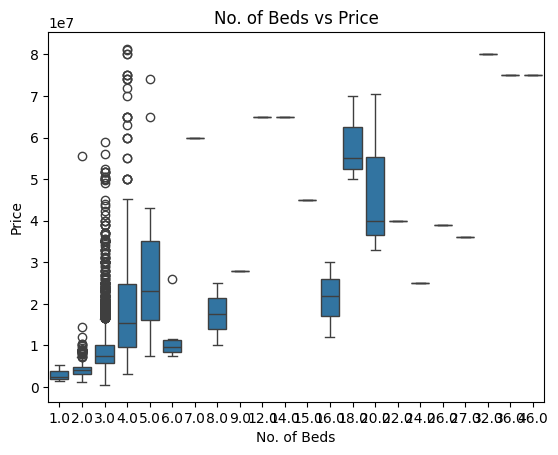

In [ ]:
# No. of Beds vs Price
sns.boxplot(x='No. Beds', y='Price', data=df)
plt.title('No. of Beds vs Price')
plt.xlabel('No. of Beds')
plt.ylabel('Price')
plt.show()

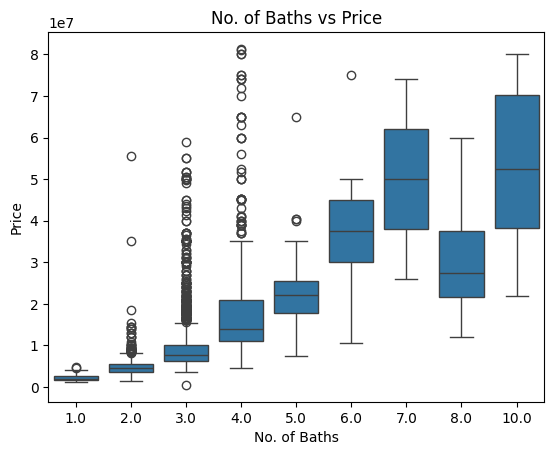

In [ ]:
# No. of Baths vs Price
sns.boxplot(x='No. Baths', y='Price', data=df)
plt.title('No. of Baths vs Price')
plt.xlabel('No. of Baths')
plt.ylabel('Price')
plt.show()


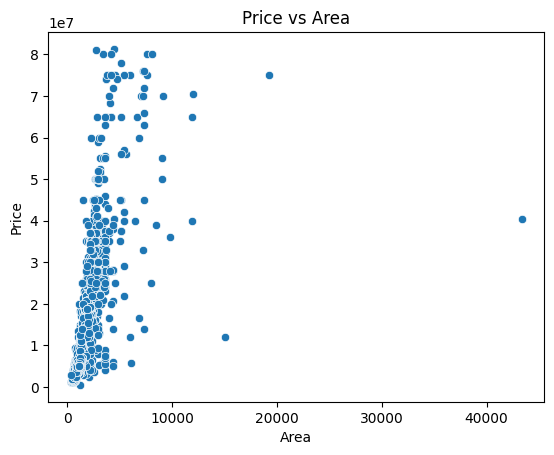

In [ ]:
# Price vs Area (scatter)
sns.scatterplot(x='Area', y='Price', data=df)
plt.title('Price vs Area')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

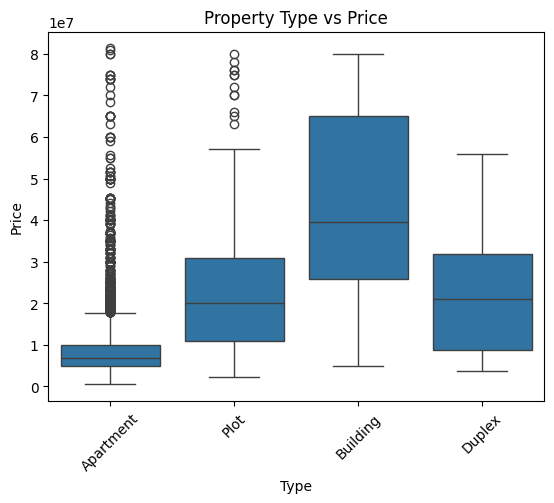

In [ ]:
#Property Type vs Price
sns.boxplot(x='Type', y='Price', data=df)
plt.title('Property Type vs Price')
plt.xlabel('Type')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()

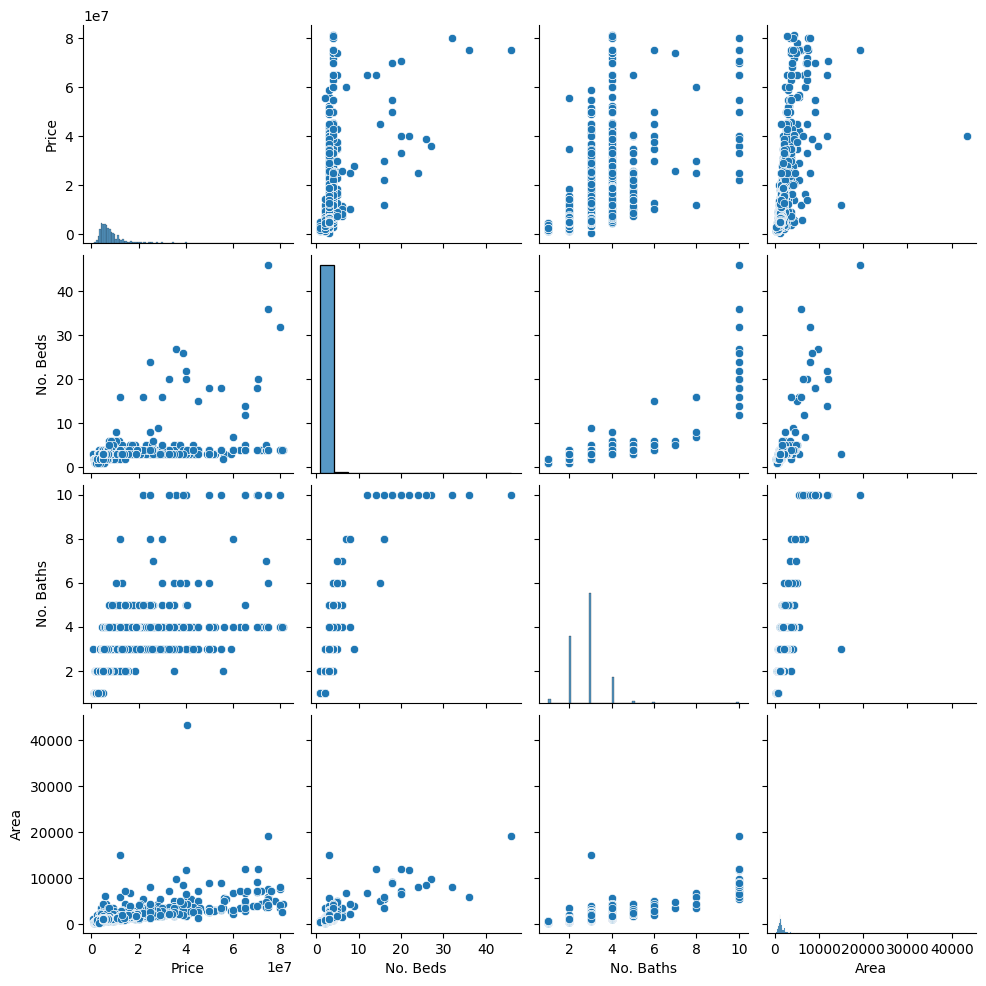

In [ ]:
# 10. Pairplot
sns.pairplot(df[['Price', 'No. Beds', 'No. Baths', 'Area']])
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Prepare data for 'No. Beds' regression
X_beds = df_filtered_imputed[['No. Beds']]
y_beds = df_filtered_imputed['Price']

# Create and fit the linear regression model for 'No. Beds'
model_beds = LinearRegression()
model_beds.fit(X_beds, y_beds)

# Make predictions and calculate R-squared
y_beds_pred = model_beds.predict(X_beds)
r2_beds = r2_score(y_beds, y_beds_pred)

print(f"R-squared for Price vs No. Beds: {r2_beds:.3f}")

R-squared for Price vs No. Beds: 0.214


In [ ]:
# Prepare data for 'No. Baths' regression
X_baths = df_filtered_imputed[['No. Baths']]
y_baths = df_filtered_imputed['Price']

# Create and fit the linear regression model for 'No. Baths'
model_baths = LinearRegression()
model_baths.fit(X_baths, y_baths)

# Make predictions and calculate R-squared
y_baths_pred = model_baths.predict(X_baths)
r2_baths = r2_score(y_baths, y_baths_pred)

print(f"R-squared for Price vs No. Baths: {r2_baths:.3f}")

R-squared for Price vs No. Baths: 0.423


In [ ]:
# Prepare data for multiple linear regression
X_multi = df_filtered_imputed[['Area', 'No. Beds', 'No. Baths']]
y_multi = df_filtered_imputed['Price']

# Create and fit the multiple linear regression model
model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)

# Print the regression coefficients and intercept
print(f"Intercept: {model_multi.intercept_:.2f}")
for i, col in enumerate(X_multi.columns):
    print(f"Coefficient for {col}: {model_multi.coef_[i]:.2f}")

# Make predictions and calculate R-squared
y_multi_pred = model_multi.predict(X_multi)
r2_multi = r2_score(y_multi, y_multi_pred)

print(f"\nR-squared for Multiple Linear Regression: {r2_multi:.3f}")

Intercept: -1846041.82
Coefficient for Area: 8765.87
Coefficient for No. Beds: -1249881.67
Coefficient for No. Baths: 669842.50

R-squared for Multiple Linear Regression: 0.648


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Add a constant to the independent variables for VIF calculation
X_vif = add_constant(df_filtered_imputed[['Area', 'No. Beds', 'No. Baths']])

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("Variance Inflation Factor (VIF):")
print(vif_data)

Variance Inflation Factor (VIF):
     feature        VIF
0      const  35.799470
1       Area   3.012823
2   No. Beds   2.002591
3  No. Baths   2.681746


In [ ]:
# Create interaction term
df_filtered_imputed['Area_Beds_Interaction'] = df_filtered_imputed['Area'] * df_filtered_imputed['No. Beds']

# Prepare data for multiple linear regression with interaction term
X_multi_interaction = df_filtered_imputed[['Area', 'No. Beds', 'No. Baths', 'Area_Beds_Interaction']]
y_multi_interaction = df_filtered_imputed['Price']

# Create and fit the multiple linear regression model
model_multi_interaction = LinearRegression()
model_multi_interaction.fit(X_multi_interaction, y_multi_interaction)

# Print the regression coefficients and intercept
print(f"Intercept: {model_multi_interaction.intercept_:.2f}")
for i, col in enumerate(X_multi_interaction.columns):
    print(f"Coefficient for {col}: {model_multi_interaction.coef_[i]:.2f}")

# Make predictions and calculate R-squared
y_multi_interaction_pred = model_multi_interaction.predict(X_multi_interaction)
r2_multi_interaction = r2_score(y_multi_interaction, y_multi_interaction_pred)

print(f"\nR-squared for Multiple Linear Regression with Interaction Term: {r2_multi_interaction:.3f}")

Intercept: -1376407.02
Coefficient for Area: 8319.50
Coefficient for No. Beds: -1420531.28
Coefficient for No. Baths: 668992.39
Coefficient for Area_Beds_Interaction: 157.60

R-squared for Multiple Linear Regression with Interaction Term: 0.649


In [ ]:
# Add a constant to the independent variables for VIF calculation
X_vif_interaction = add_constant(df_filtered_imputed[['Area', 'No. Beds', 'No. Baths', 'Area_Beds_Interaction']])

# Calculate VIF for each independent variable
vif_data_interaction = pd.DataFrame()
vif_data_interaction["feature"] = X_vif_interaction.columns
vif_data_interaction["VIF"] = [variance_inflation_factor(X_vif_interaction.values, i) for i in range(X_vif_interaction.shape[1])]

print("Variance Inflation Factor (VIF) with Interaction Term:")
print(vif_data_interaction)

Variance Inflation Factor (VIF) with Interaction Term:
                 feature         VIF
0                  const  306.373590
1                   Area   25.831580
2               No. Beds   10.366771
3              No. Baths    2.682114
4  Area_Beds_Interaction   51.411902


In [ ]:
average_price_by_beds = df_filtered_imputed.groupby('No. Beds')['Price'].mean().reset_index()
print("Average Price by Number of Beds:")
print(average_price_by_beds)

Average Price by Number of Beds:
   No. Beds         Price
0       1.0  2.953846e+06
1       2.0  4.197495e+06
2       3.0  7.801567e+06
3       4.0  9.872250e+06
4       5.0  1.083333e+07
5       6.0  8.190000e+06
